In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import perceval as pcvl
from exqalibur import FockState
from IPython.display import Markdown, display

In [3]:
### --- SOURCE ---
'''
Decoy State Implementation is not tractable currently as pcvl Source class
    does not support alternative mean photon number definitions, instead
    we employ statistical Poisson Analysis
'''
decoy_states = [0, 0.6, 1, 1.2]
decoy_states_source = {}

def Poisson_p(n, mean):
    return math.exp(-mean) * mean**n / math.factorial(n)

for mean_photon_n in decoy_states:
    if mean_photon_n == 0:
        # pcvl.Source() cannot model vaccum states
        wcp_source = None
        continue
    # According to Poisson Distribution, what is P(n >= 2)?
    emission_probability = 1 - Poisson_p(0, mean_photon_n)
    multiphoton_probability = emission_probability - Poisson_p(1, mean_photon_n)

    wcp_source = pcvl.Source(
        emission_probability = emission_probability,
        multiphoton_component = multiphoton_probability,
        losses = 0 
    )
    decoy_states_source[mean_photon_n] = wcp_source

In [4]:
def fock_string(
    index,
    length,
    index_annotation = 1
):
    fock_list = [0] * length
    fock_list[index] = index_annotation
    return f"|{",".join(map(str, fock_list))}>"


print(f"Photon in First Mode: {fock_string(0, 4)}")
print(f"Photon in Third Mode: {fock_string(2, 4)}")
print(f"Vaccum State: {fock_string(0, 4, index_annotation = 0)}")
print(f"H-Photon in First Mode: {fock_string(0, 4, index_annotation = "{P:H}")}")

Photon in First Mode: |1,0,0,0>
Photon in Third Mode: |0,0,1,0>
Vaccum State: |0,0,0,0>
H-Photon in First Mode: |{P:H},0,0,0>


In [5]:
### --- CIRCUIT ---
### NON DECOY IMPLEMENTATION
"""
ALICE
1. One WCP source selected from the Poisson/decoy SOURCE cell
2. One HWP whose angle is randomized each BB84 shot to prepare H, V, D, or A
3. Lossy free-space channel

BOB
1. HWP for basis choice
2. PBS
3. Two detectors

EVE MODEL 1
Passive beam-splitter wiretap. Eve always taps the channel and measures her branch.
"""

alice_mean = 0.6
rng_seed = 2
rng = np.random.default_rng(rng_seed)

alice_hwp_angles = {
    "H": 0,
    "V": np.pi / 4,
    "D": np.pi / 8,
    "A": -np.pi / 8,
}

alice_state_metadata = {
    "H": {"basis": "Z", "bit": 0},
    "V": {"basis": "Z", "bit": 1},
    "D": {"basis": "X", "bit": 0},
    "A": {"basis": "X", "bit": 1},
}

measurement_hwp_angles = {
    "Z": 0,
    "X": np.pi / 8,
}

measurement_detector_labels = {
    "Z": {0: "H", 1: "V"},
    "X": {0: "D", 1: "A"},
}

bb84_states = list(alice_hwp_angles.keys())
bb84_bases = list(measurement_hwp_angles.keys())
alice_source = decoy_states_source[alice_mean]
alice_nominal_input = pcvl.BasicState("|{P:H}>")

def make_alice_preparation_circuit(state_label):
    circuit = pcvl.Circuit(1, name = f"Alice Prep ({state_label})")
    circuit.add(0, pcvl.HWP(xsi = alice_hwp_angles[state_label]))
    return circuit

def make_measurement_subsystem(basis_label, name):
    subsystem = pcvl.Circuit(2, name = name)
    subsystem.add(0, pcvl.HWP(xsi = measurement_hwp_angles[basis_label]))
    subsystem.add(0, pcvl.PBS())
    return subsystem

def build_eve_model_1_processor(
    state_label,
    bob_basis,
    eve_basis,
    channel_loss_before_tap,
    eve_tap_reflectivity,
    bob_channel_loss,
    eve_channel_loss,
    z_phase_jitter = 0
):
    alice_circuit = make_alice_preparation_circuit(state_label)
    bob_circuit = make_measurement_subsystem(bob_basis, name = f"Bob Measurement ({bob_basis})")
    eve_circuit = make_measurement_subsystem(eve_basis, name = f"Eve Measurement ({eve_basis})")
    noise_circuit = pcvl.Circuit(1, name = f"Channel Misalignment")
    noise_circuit.add(0, pcvl.HWP(xsi = z_phase_jitter))

    processor = pcvl.Processor("Naive", 4)
    processor.add(0, alice_circuit)
    processor.add(0, pcvl.LC(loss = channel_loss_before_tap))
    processor.add(0, noise_circuit)
    processor.add([0, 2], pcvl.BS.Rx(theta = pcvl.BS.r_to_theta(eve_tap_reflectivity)))
    processor.add(2, pcvl.LC(loss = bob_channel_loss))
    processor.add(0, pcvl.LC(loss = eve_channel_loss))
    processor.add([2, 3], bob_circuit)
    processor.add([0, 1], eve_circuit)
    processor._source = alice_source
    processor.with_input(pcvl.BasicState(fock_string(0, 4, index_annotation = "{P:H}")))
    processor.min_detected_photons_filter(0)
    return processor

def sample_output_state(distribution, rng):
    states = list(distribution.keys())
    probabilities = np.array(list(distribution.values()), dtype = float)
    probabilities = probabilities / probabilities.sum()
    return states[rng.choice(len(states), p=probabilities)]

def decode_measurement(
    output_state,
    basis_label,
    first_mode,
    second_mode,
    click_threshold = 0
):
    first_clicks = int(output_state[first_mode])
    second_clicks = int(output_state[second_mode])
    total_clicks = first_clicks + second_clicks

    if total_clicks <= click_threshold:
        return {"symbol": "no click", "bit": None}
    if first_clicks > click_threshold and second_clicks <= click_threshold:
        return {"symbol": measurement_detector_labels[basis_label][0], "bit": 0}
    if second_clicks > click_threshold and first_clicks <= click_threshold:
        return {"symbol": measurement_detector_labels[basis_label][1], "bit": 1}
    return {"symbol": "double click", "bit": None}


In [6]:
def protocol_eve_model_1(
    n_trials,
    channel_loss_before_tap,
    eve_tap_reflectivity,
    bob_channel_loss,
    eve_channel_loss,
    run_click = False,
    run_probs = True,
    add_dephasing = True,
    max_random_dephase = np.pi/16,
):
    run_probs = not run_click
    bb84_trial_records = []

    for trial_index in range(n_trials):
        alice_state = rng.choice(bb84_states)
        bob_basis = rng.choice(bb84_bases)
        eve_basis = rng.choice(bb84_bases)
        
        random_phase_jitter = 0
        if add_dephasing:
            random_phase_jitter = rng.uniform(0, max_random_dephase)
        eve_model_1_processor = build_eve_model_1_processor(
                alice_state,
                bob_basis,
                eve_basis,
                channel_loss_before_tap = channel_loss_before_tap,
                eve_tap_reflectivity = eve_tap_reflectivity,
                bob_channel_loss = bob_channel_loss,
                eve_channel_loss = eve_channel_loss,
                z_phase_jitter = random_phase_jitter
        )
        
        eve_model_1_distribution = eve_model_1_processor.probs()["results"]
        sampled_output_state = sample_output_state(eve_model_1_distribution, rng)
        if run_click:
            sampled_output_state = sample_output_state(eve_model_1_distribution, rng)
            bob_observation = decode_measurement(sampled_output_state, bob_basis, 2, 3)
            eve_observation = decode_measurement(sampled_output_state, eve_basis, 0, 1)

            bb84_trial_records.append({
                "trial": trial_index,
                "alice_state": alice_state,
                "alice_basis": alice_state_metadata[alice_state]["basis"],
                "alice_bit": alice_state_metadata[alice_state]["bit"],
                "bob_basis": bob_basis,
                "bob_symbol": bob_observation["symbol"],
                "bob_bit": bob_observation["bit"],
                "eve_basis": eve_basis,
                "eve_symbol": eve_observation["symbol"],
                "eve_bit": eve_observation["bit"]
            })
            
        def quick_eve_distribution_search(index, round_precision, index_annotation = 1):
            return  round(eve_model_1_distribution[FockState(fock_string(index, 4, index_annotation = index_annotation))], round_precision)
            
        if run_probs:    
            bb84_trial_records.append({
                "trial": trial_index,
                "alice_state": alice_state,
                "alice_basis": alice_state_metadata[alice_state]["basis"],
                "alice_bit": alice_state_metadata[alice_state]["bit"],
                "phase_drift": f"{round(random_phase_jitter * 180 / np.pi, 2)}°",
                "bob_basis": bob_basis,
                "bob_detect_0": quick_eve_distribution_search(2, 4),
                "bob_detect_1": quick_eve_distribution_search(3, 4),
                "eve_basis": eve_basis,
                "eve_detect_0": quick_eve_distribution_search(0, 4),
                "eve_detect_1": quick_eve_distribution_search(1, 4),
                "vaccum_probability": quick_eve_distribution_search(2, 4, index_annotation = 0),
            })

    return bb84_trial_records

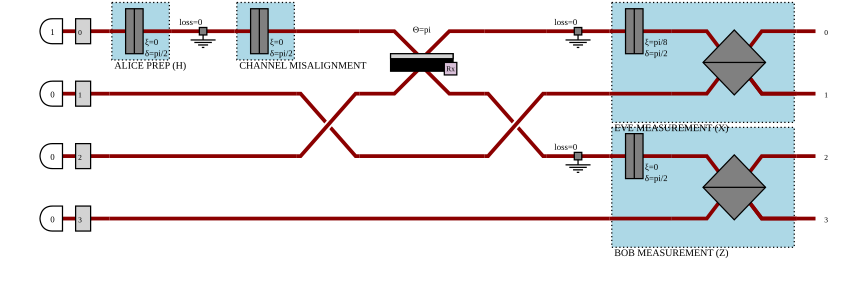

#### Trial Summary
Alice's HWP angle is randomized each shot with RNG seed `2` over trials. 

| trial | alice_state | alice_basis | alice_bit | phase_drift | bob_basis | bob_detect_0 | bob_detect_1 | eve_basis | eve_detect_0 | eve_detect_1 | vaccum_probability |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | A | X | 1 | 9.16° | Z | 0.2644 | 0.0668 | Z | 0.3966 | 0.1002 | 0.172 |
| 1 | V | Z | 1 | 8.2° | Z | 0.3048 | 0.0264 | X | 0.3829 | 0.1139 | 0.172 |
| 2 | A | X | 1 | 7.4° | Z | 0.2474 | 0.0838 | X | 0.0324 | 0.4644 | 0.172 |
| 3 | V | Z | 1 | 4.87° | Z | 0.3217 | 0.0095 | Z | 0.4826 | 0.0142 | 0.172 |
| 4 | A | X | 1 | 10.88° | Z | 0.2797 | 0.0515 | Z | 0.4195 | 0.0773 | 0.172 |
| 5 | D | X | 0 | 2.11° | Z | 0.1413 | 0.1899 | Z | 0.212 | 0.2848 | 0.172 |
| 6 | D | X | 0 | 8.73° | X | 0.3014 | 0.0298 | X | 0.4521 | 0.0447 | 0.172 |
| 7 | A | X | 1 | 5.3° | X | 0.0112 | 0.32 | X | 0.0168 | 0.48 | 0.172 |
| 8 | D | X | 0 | 2.27° | Z | 0.1394 | 0.1918 | Z | 0.2092 | 0.2876 | 0.172 |
| 9 | H | Z | 0 | 9.55° | X | 0.0632 | 0.268 | X | 0.0947 | 0.4021 | 0.172 |

In [8]:
### --- VISUALIZATION ---
eve_model_1_processor = build_eve_model_1_processor(
    "H",
    "Z",
    "X",
    *[0]*4
)

display(pcvl.pdisplay(eve_model_1_processor, recursive = True))


def records_to_markdown_table(records):
    column_names = records[0].keys()
    header = f"| {" | ".join(column_names)} |"
    separator = f"{"|:---:" * len(column_names)}|"
    rows = []
    for record in records:
        rows.append(
            f"| {" | ".join(map(str, record.values()))} |"
        )
    return "\n".join([header, separator] + rows)

pcvl.pdisplay(eve_model_1_processor, recursive = True)

display(Markdown(
    f"#### Trial Summary\n"
    f"Alice's HWP angle is randomized each shot with RNG seed `{rng_seed}` over trials. "
))


### RUN SIMULATION:
bb84_trial_records = protocol_eve_model_1(
    n_trials = 100,
    channel_loss_before_tap = 0.1,
    eve_tap_reflectivity = 0.6,
    bob_channel_loss = 0.08,
    eve_channel_loss = 0.08
)
display(Markdown(records_to_markdown_table(bb84_trial_records[:10])))


KeyError: 'P(Bob correct)'

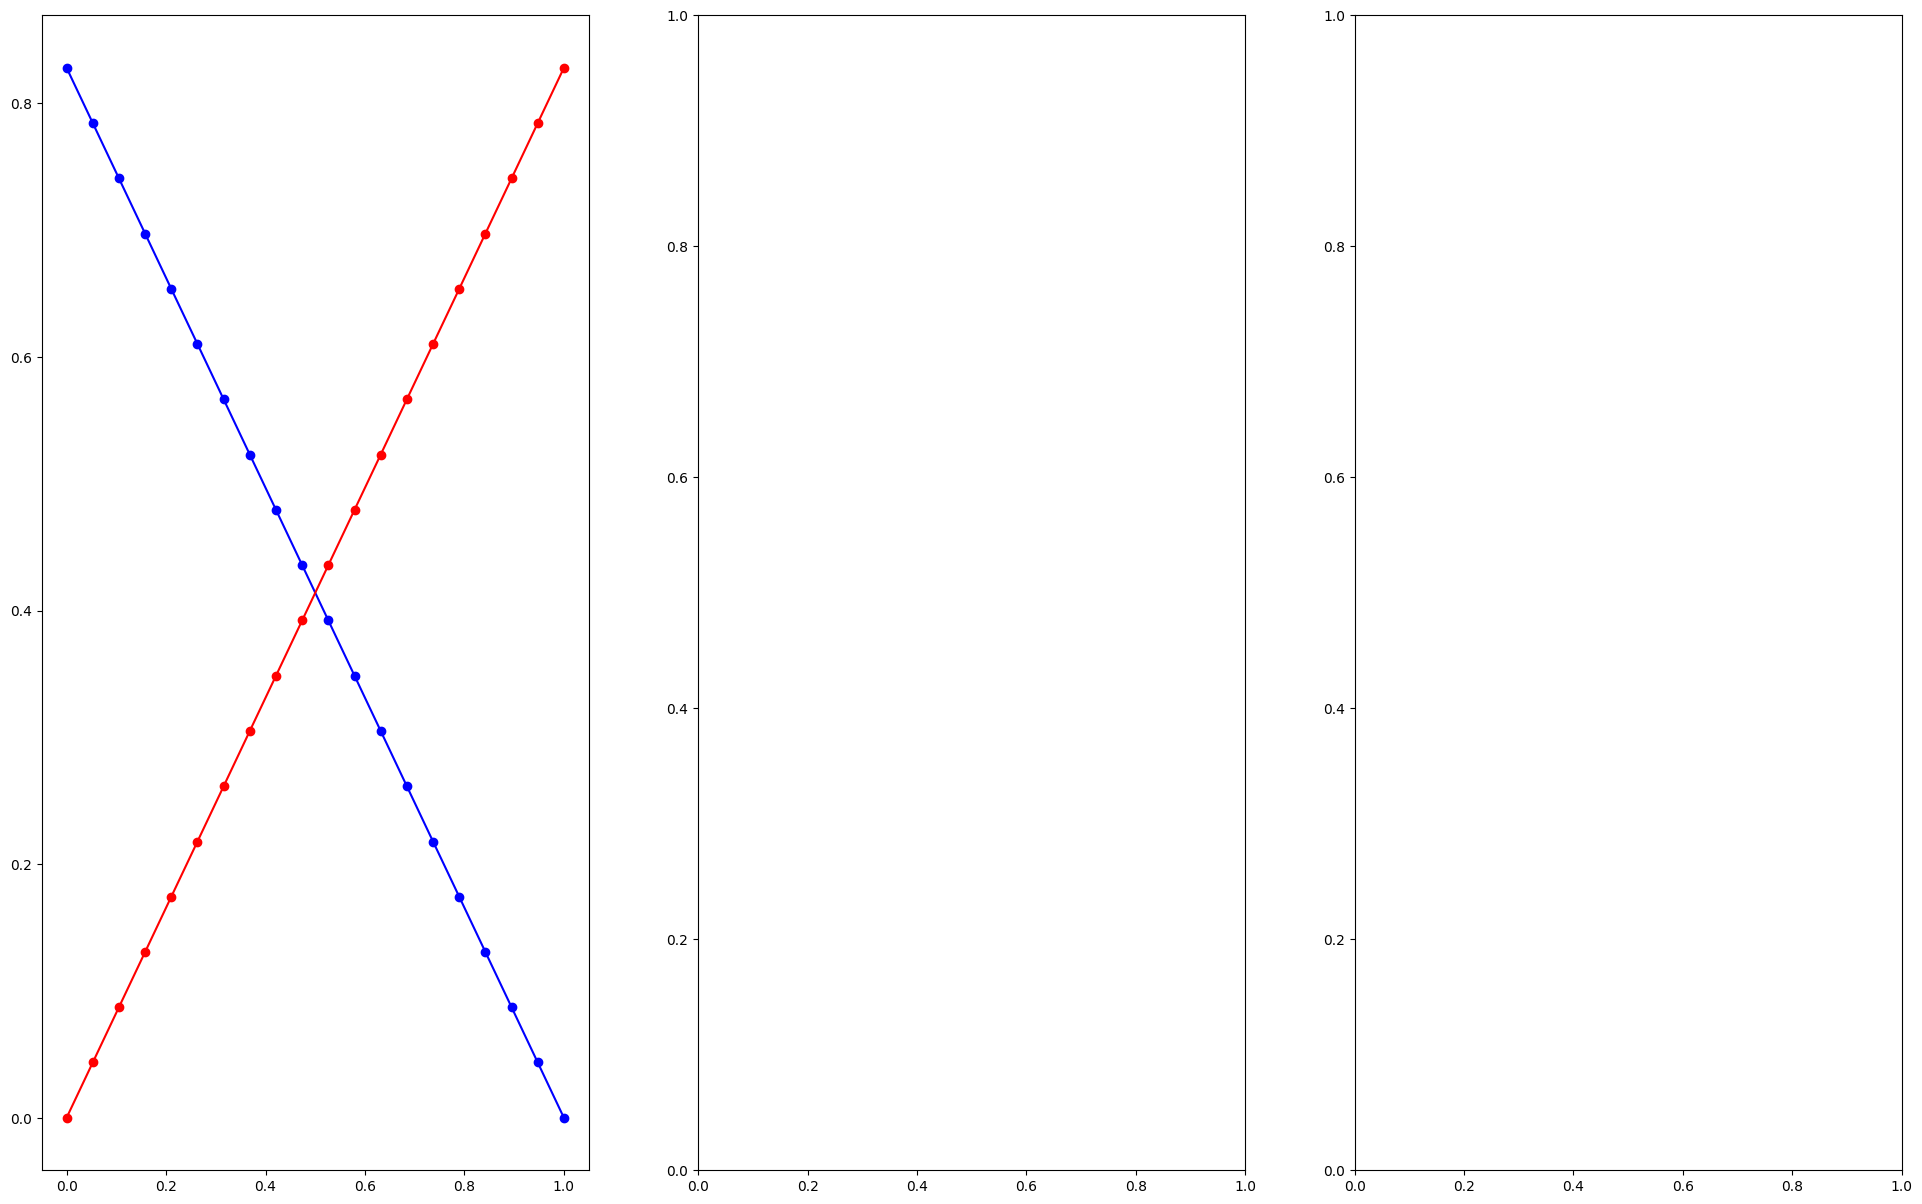

In [12]:
### --- REFLECTIVITY TEST: P(BOB CLICK) SUPERPOSITIONS ---
'''
How changing Eve's beam-splitter reflectivity changes Bob's click probability.
Metric used here: P(Bob click) = average over trials of (bob_detect_0 + bob_detect_1)
'''

import pandas as pd

def bob_click_metric(records):
    return np.mean([
        float(record["bob_detect_0"]) + float(record["bob_detect_1"])
        for record in records
    ])
    
def eve_click_metric(records):
    return np.mean([
        float(record["eve_detect_0"]) + float(record["eve_detect_1"])
        for record in records
    ])
    
def bob_average_llr(records, eps = 1e-12):
    matched = [r for r in records if r["alice_basis"] == r["bob_basis"]]
    llrs = []
    for r in matched:
        p0 = float(r["bob_detect_0"])
        p1 = float(r["bob_detect_1"])
        if r["alice_bit"] == 0:
            llrs.append(np.log((p0 + eps) / (p1 + eps)))
        else:
            llrs.append(np.log((p1 + eps) / (p0 + eps)))
    return np.mean(llrs)

def eve_average_llr(records, eps = 1e-12):
    matched = [r for r in records if r["alice_basis"] == r["eve_basis"]]
    llrs = []
    for r in matched:
        p0 = float(r["eve_detect_0"])
        p1 = float(r["eve_detect_1"])
        if r["alice_bit"] == 0:
            llrs.append(np.log((p0 + eps) / (p1 + eps)))
        else:
            llrs.append(np.log((p1 + eps) / (p0 + eps)))
    return np.mean(llrs)


def run_reflectivity_sweep(
    reflectivity_values,
    channel_loss_before_tap_value = 0.1,
    bob_channel_loss_value = 0.08,
    eve_channel_loss_value = 0.08,
    max_random_dephase = 0
):
    rows = []
    for reflectivity in reflectivity_values:
        trial_records = protocol_eve_model_1(
            n_trials = 1000,
            channel_loss_before_tap = channel_loss_before_tap_value,
            eve_tap_reflectivity = reflectivity,
            bob_channel_loss = bob_channel_loss_value,
            eve_channel_loss = eve_channel_loss_value,
            max_random_dephase = max_random_dephase
        )
        rows.append({
            "eve_tap_reflectivity": reflectivity,
            "P(Bob click)": bob_click_metric(trial_records),
            "P(Eve click)": eve_click_metric(trial_records),
            "P(Eve LLR)": bob_average_llr(trial_records),
            "P(Bob LLR)": eve_average_llr(trial_records)
        })
    return pd.DataFrame(rows)

# Sweep reflectivity directly.
reflectivity_values = np.linspace(0, 1, 20)

sweep_df = run_reflectivity_sweep(
    reflectivity_values
)


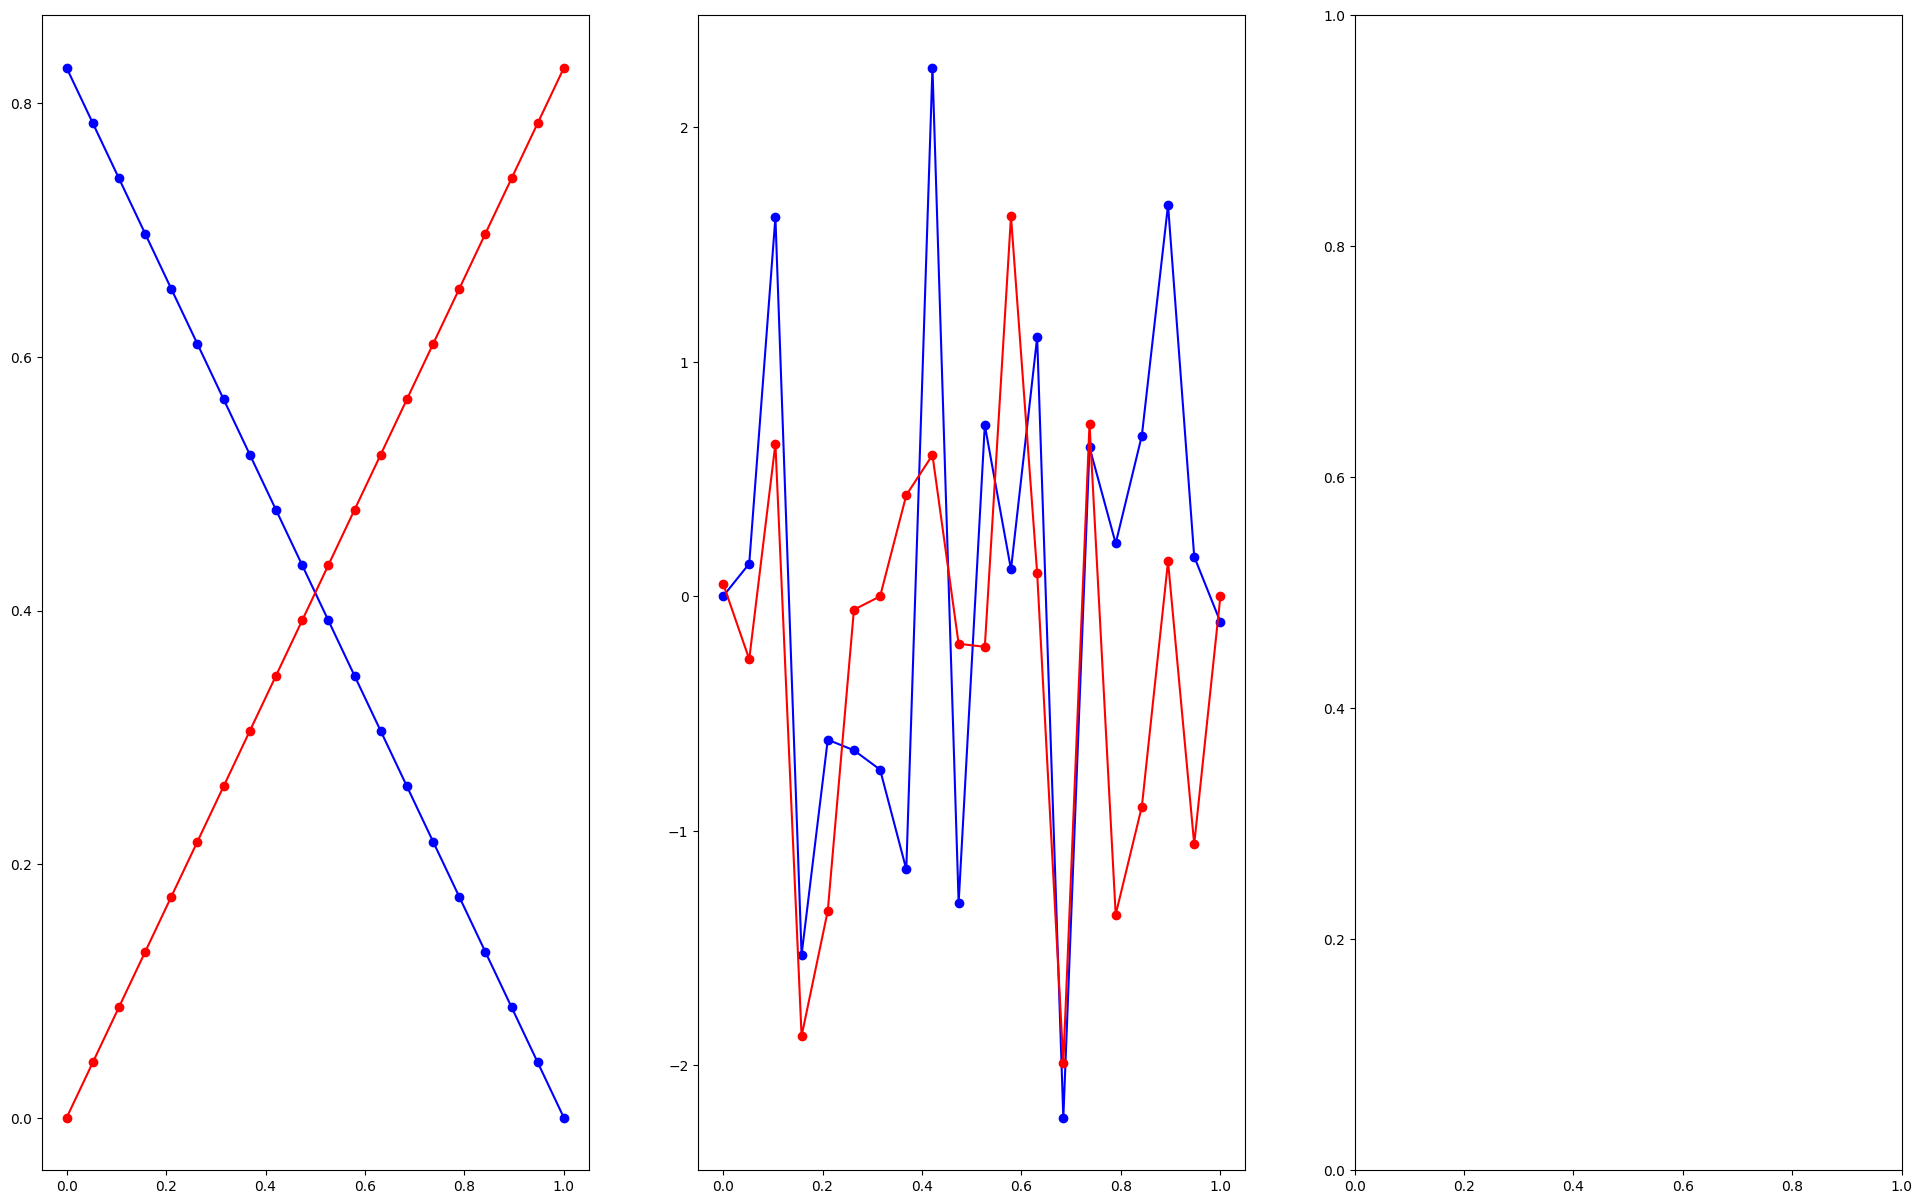

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 15))

axes[0].plot(
    sweep_df["eve_tap_reflectivity"], 
    sweep_df["P(Bob click)"], 
    marker="o",
    color = "blue"
)

axes[0].plot(
    sweep_df["eve_tap_reflectivity"], 
    sweep_df["P(Eve click)"], 
    marker="o",
    color = "red"
)

axes[1].plot(
    sweep_df["eve_tap_reflectivity"], 
    sweep_df["P(Bob LLR)"], 
    marker="o",
    color = "blue"
)

axes[1].plot(
    sweep_df["eve_tap_reflectivity"], 
    sweep_df["P(Eve LLR)"], 
    marker="o",
    color = "red"
)